# Analysis of RPKM Tables via Volcano Plot

In [1]:
import os
import numpy as np
import pandas as pd
import json

import mygene

import matplotlib.pyplot as plt
import plotly.express as px


rpkm = r"../rpkm_values/rpkm_combined.txt"
healthy = r"../rpkm_values/rpkm_healthy/rpkm_values_healthy.txt"
t2d = r"../rpkm_values/rpkm_t2d/rpkm_values_t2d.txt"

In [2]:
df_combined = pd.read_csv(rpkm, sep='\t')
df_healthy = pd.read_csv(healthy, sep='\t')
df_t2d = pd.read_csv(t2d, sep='\t')

In [3]:
print(len(df_combined.columns))
print(len(df_healthy.columns))
print(len(df_t2d.columns))

142
97
45


In [4]:
# Transpose the RPKM dataframe so rows become samples
df = df_combined.T

# Now determine sample labels
healthy_samples = set(df_healthy.columns)
t2d_samples = set(df_t2d.columns)

# Assign condition based on sample name
df['condition'] = ['healthy' if sample in healthy_samples else 't2d' for sample in df.index]
# Add donor name column
df['donor'] = df.index.str.split('_').str[0]



In [5]:
t2d_samples

{'HP1504101T2D_B6.bam',
 'HP1504101T2D_C18.bam',
 'HP1504101T2D_D9.bam',
 'HP1504101T2D_E15.bam',
 'HP1504101T2D_E16.bam',
 'HP1504101T2D_E24.bam',
 'HP1504101T2D_H23.bam',
 'HP1504101T2D_H6.bam',
 'HP1504101T2D_N10.bam',
 'HP1504101T2D_O12.bam',
 'HP1508501T2D_B16.bam',
 'HP1508501T2D_I8.bam',
 'HP1508501T2D_J6.bam',
 'HP1526901T2D_A1.bam',
 'HP1526901T2D_A14.bam',
 'HP1526901T2D_A19.bam',
 'HP1526901T2D_A2.bam',
 'HP1526901T2D_A5.bam',
 'HP1526901T2D_B1.bam',
 'HP1526901T2D_E11.bam',
 'HP1526901T2D_E2.bam',
 'HP1526901T2D_G17.bam',
 'HP1526901T2D_G21.bam',
 'HP1526901T2D_G4.bam',
 'HP1526901T2D_H10.bam',
 'HP1526901T2D_H20.bam',
 'HP1526901T2D_H22.bam',
 'HP1526901T2D_H24.bam',
 'HP1526901T2D_H4.bam',
 'HP1526901T2D_I13.bam',
 'HP1526901T2D_I3.bam',
 'HP1526901T2D_J21.bam',
 'HP1526901T2D_K20.bam',
 'HP1526901T2D_K23.bam',
 'HP1526901T2D_K3.bam',
 'HP1526901T2D_K7.bam',
 'HP1526901T2D_L1.bam',
 'HP1526901T2D_L5.bam',
 'HP1526901T2D_M15.bam',
 'HP1526901T2D_N1.bam',
 'HP1526901T2D_N12

In [6]:
# Create a dictionary mapping ensembl_ids to gene symbols

ensembl_ids = list(df.drop(columns=['condition', 'donor']).columns)

query_cache_file = "ensembl_symbol_cache.json"

# Batch query: return gene symbol for each Ensembl ID (This will take 2 minutes)
if os.path.exists(query_cache_file):
    with open(query_cache_file, "r") as f:
        query_result = json.load(f)
    print(f"Loaded cached MyGene.info results from {query_cache_file}")
else:
    mg = mygene.MyGeneInfo()
    query_result = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

    # Save for future reuse
    with open(query_cache_file, "w") as f:
        json.dump(query_result, f)
    print(f"Fetched MyGene.info results and cached to {query_cache_file}")

# Build a mapping: ENSG ID → gene symbol
ensembl_to_symbol = {
    item['query']: item.get('symbol', item['query'])  # fallback to ENSG ID if no symbol found
    for item in query_result
}

no_hit_count = sum(1 for item in query_result if item.get('notfound', False))
print(f"{len(ensembl_to_symbol) - no_hit_count} of {len(ensembl_ids)} ensembl to symbol mapped")

Loaded cached MyGene.info results from ensembl_symbol_cache.json
61474 of 62710 ensembl to symbol mapped


In [7]:
# Rename columns from ensembl ids to gene ids
df.rename(columns=ensembl_to_symbol, inplace=True)
gene_ids = list(df.drop(columns=['condition', 'donor']).columns)
len(gene_ids)

62710

## Trimming Low-Expression Genes
(represented in fewer than 5 cells)

In [8]:
df_filtered = df.drop(columns=['condition', 'donor'])

In [9]:
df_filtered = df_filtered.loc[:, (df_filtered > 0).sum(axis=0) > 5]

In [10]:
df_filtered.shape

(142, 16361)

In [11]:
df_filtered = pd.concat([df[['condition', 'donor']], df_filtered], axis=1)

## Volcano Plot
16361 genes

In [27]:
# Separate data
t2d = df_filtered[df_filtered['condition'] == 't2d']
healthy = df_filtered[df_filtered['condition'] == 'healthy']

# Remove duplicates
df_filtered = df_filtered.loc[:, ~df_filtered.columns.duplicated()]

# Get gene names (excluding metadata)
gene_columns = [col for col in df_filtered.columns if col not in ['condition', 'donor']]

In [28]:
from scipy.stats import ttest_ind

# Compute log2 fold changes and p-values
log2fc = []
pvals = []

for gene in gene_columns:
    t2d_vals = t2d[gene]
    healthy_vals = healthy[gene]
    
    # Mean values
    try:
        mean_t2d = float(t2d_vals.mean())
    except:
        print(gene, type(t2d[gene]))
    mean_healthy = float(healthy_vals.mean())

    
    # Safe log2 fold change
    fc = (mean_t2d + 1e-9) / (mean_healthy + 1e-9)
    log2fc.append(float(np.log2(fc)))

    # t-test with robust scalar conversion
    try:
        t_stat, p = ttest_ind(t2d_vals.values, healthy_vals.values, equal_var=False)
        pvals.append(float(p))
    except Exception:
        pvals.append(1.0)  # fallback if error occurs


# Assemble results
volcano_df = pd.DataFrame({
    'gene': gene_columns,
    'log2FC': log2fc,
    'pval': pvals,
    '-log10(pval)': -np.log10(pvals)
})

In [29]:
# Categorize for coloring
def color_code(row):
    if row['pval'] > 0.05:
        return 'gray'
    elif row['log2FC'] > 0:
        return 'red'
    else:
        return 'blue'

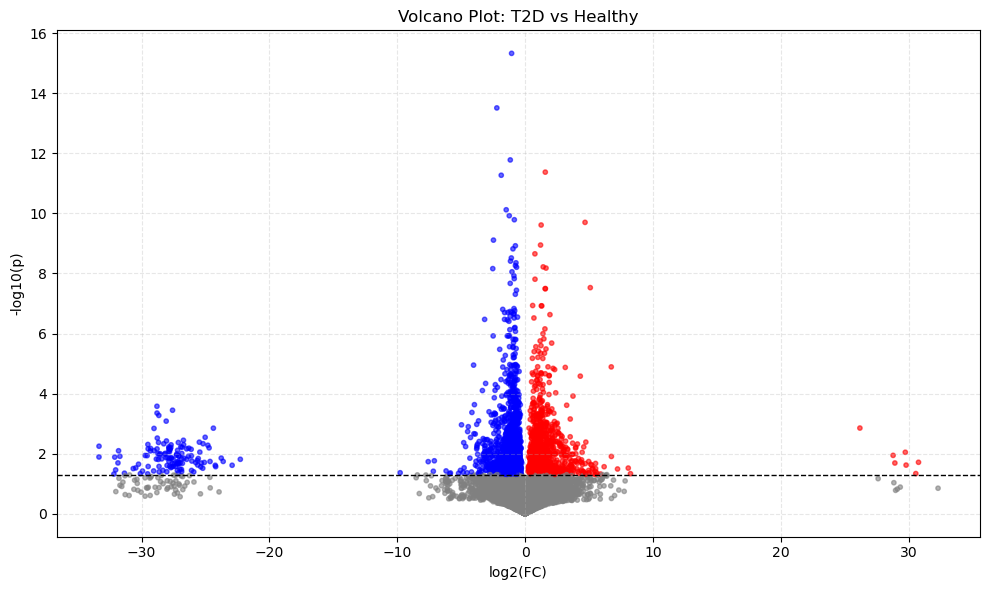

In [31]:
volcano_df['color'] = volcano_df.apply(color_code, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(volcano_df['log2FC'], volcano_df['-log10(pval)'],
            c=volcano_df['color'], alpha=0.6, s=10)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
plt.xlabel('log2(FC)')
plt.ylabel('-log10(p)')
plt.title('Volcano Plot: T2D vs Healthy')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
volcano_df_filtered = volcano_df[
    (volcano_df['log2FC'] >= -10) & (volcano_df['log2FC'] <= 10)
].copy()


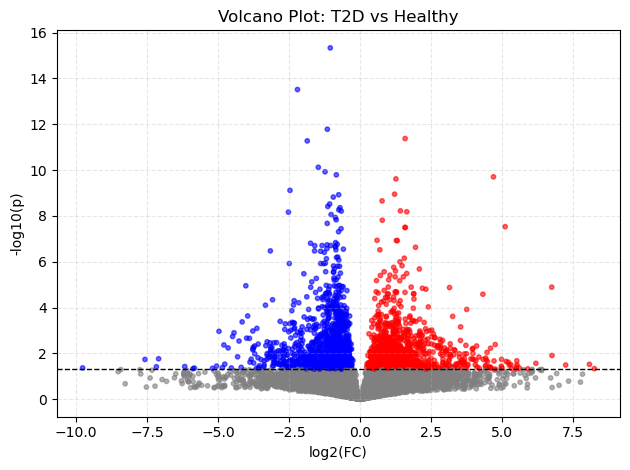

In [34]:
plt.scatter(
    volcano_df_filtered['log2FC'],
    volcano_df_filtered['-log10(pval)'],
    c=volcano_df_filtered['color'],
    alpha=0.6, s=10
)
plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
plt.xlabel('log2(FC)')
plt.ylabel('-log10(p)')
plt.title('Volcano Plot: T2D vs Healthy')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
top_genes = volcano_df_filtered.nsmallest(10, 'pval')


In [50]:
fc_thresh = 1  # minimum log2FC threshold
p_thresh = 0.05

top_genes = volcano_df_filtered[
    (volcano_df_filtered['pval'] < p_thresh) &
    (volcano_df_filtered['log2FC'].abs() > fc_thresh)
].copy()

top_genes = top_genes.sort_values(by='log2FC', key=np.abs, ascending=False).head(10)


In [52]:
# These are genes commonly-linked to T2D
t2d_genes = [
    "TCF7L2", "CDKAL1", "KCNJ11", "PPARG", "HHEX", "SLC30A8", "IGF2BP2", "CDKN2A", "CDKN2B",
    "FTO", "MC4R", "CDC123", "PHF2", "SLC16A11", "ANK1", "NOTCH2", "JAZF1", "WFS1", "GLIS3",
    "GCK", "GCKR", "HNF1A", "HNF4A", "PAX5", "TET1", "CHL1", "GLRA1", "IAPP", "CAPN10", "ABCC8",
    "GCGR", "ADAMTS9", "ADIPOQ", "IRS1", "SREBF1", "EXT2", "MEF2C", "TMEM161B", "CEP120", 
    "PRDM6", "STEAP1", "ZNF804B", "ZNRF3", "PRIM1", "IRF2BPL", "LRRC74A"
]
genes_of_interest = ['INS', 'GCG', 'SST', 'PPY'] + t2d_genes
genes_of_interest = ['FXYD2', 'TTR', 'MEG3', 'ATP6V1G1', 'EGFR', 'DDO', 'B3GNT7']
top_genes = volcano_df_filtered[volcano_df_filtered['gene'].isin(genes_of_interest)]

set(top_genes.index) & set(t2d_genes)

set()

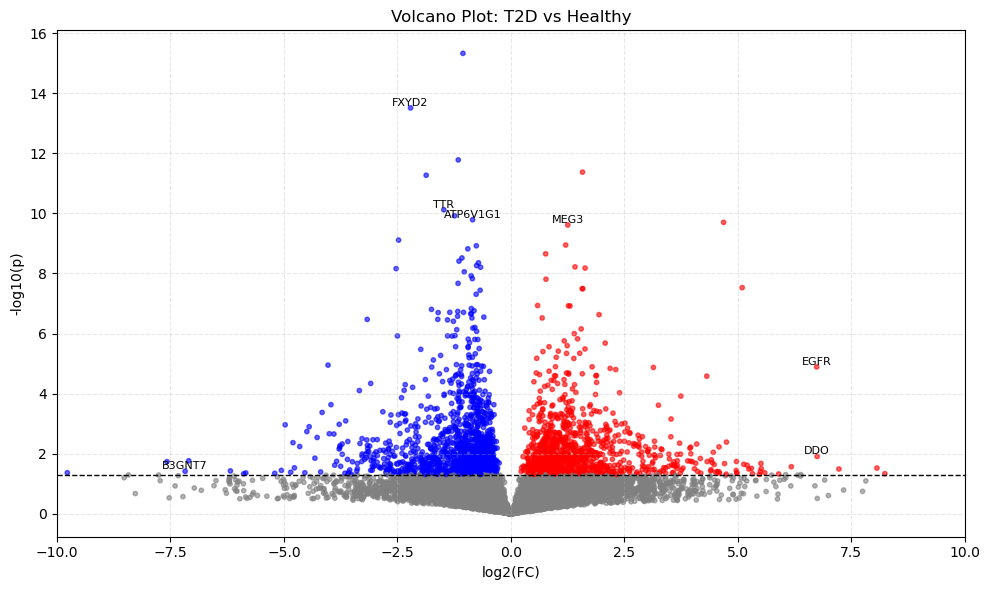

In [59]:
plt.figure(figsize=(10, 6))

plt.scatter(
    volcano_df_filtered['log2FC'],
    volcano_df_filtered['-log10(pval)'],
    c=volcano_df_filtered['color'],
    alpha=0.6, s=10
)

for _, row in top_genes.iterrows():
    plt.text(row['log2FC'], row['-log10(pval)'], row['gene'],
             fontsize=8, ha='center', va='bottom')

plt.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=1)
plt.xlabel('log2(FC)')
plt.xlim((-10, 10))
plt.ylabel('-log10(p)')
plt.title('Volcano Plot: T2D vs Healthy')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
(top_genes['gene'])

4154               ZGRF1
12991             NPIPB2
3517           LINC02044
3577        ARHGEF26-AS1
527      ENSG00000260920
1998              B3GNT7
9930           DIP2C-AS1
5455                 DDO
6699                EGFR
4533     ENSG00000249159
Name: gene, dtype: object

In [ ]:
['FXYD2', 'TTR', 'MEG3', 'ATP6V1G1', 'EGFR', 'DDO', 'B3GNT7']